Beta distribution is parameterized by shape parameters $\alpha$ and $\beta$. When $\alpha = \beta = 1$, we recover the uniform distribution. As $\alpha, \beta \to 0$, the distribution concentrates mass at the boundaries.


- $\alpha = 1.0$: Uniform sampling (no importance sampling baseline)
- $\alpha = 0.5$: Moderate boundary concentration
- $\alpha = 0.3$: Heavy boundary concentration  
- $\alpha = 0.1$: Extreme boundary concentration

For each strategy, we train a GRU model and evaluate on 20000 uniformly sampled test cases to ensure robust performance metrics.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import torch
import torch.nn as nn
from tqdm import tqdm

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 3060


In [2]:
# Configuration
A = 5.0  
T = 64   

# Importance sampling strategies to compare
ALPHA_VALUES = [1.0, 0.5, 0.3, 0.1]

# Training hyperparameters
N_EPOCHS = 128
N_BATCHES_PER_EPOCH = 128
TRAINING_BATCH_SIZE = 128

# Evaluation: 20x standard size to ensure robust metrics
N_EVAL_POINTS = 20000

# For sigma proposal, we use Beta(alpha, 2) to push towards low sigma
# This differs from rho where we use Beta(alpha, alpha) for symmetric boundaries
BETA_SIGMA = 1

In [3]:
def sample_from_proposal(batch_size, alpha_rho, alpha_sigma, beta_sigma, A, device='cpu'):
    """Sample (rho, sigma) from Beta-based proposal"""
    rho_tilde = np.random.beta(alpha_rho, alpha_rho, size=batch_size)
    sigma_tilde = np.random.beta(alpha_sigma, beta_sigma, size=batch_size)
    
    rho = 2 * rho_tilde - 1
    sigma = A * sigma_tilde
    
    rho = torch.tensor(rho, dtype=torch.float32, device=device)
    sigma = torch.tensor(sigma, dtype=torch.float32, device=device)
    
    return rho, sigma

def compute_importance_weights(rho, sigma, alpha_rho, alpha_sigma, beta_sigma, A):
    """Compute importance weights w = p(theta) / q(theta)"""
    if torch.is_tensor(rho):
        rho = rho.cpu().numpy()
        sigma = sigma.cpu().numpy()
    
    rho_tilde = (rho + 1) / 2
    sigma_tilde = sigma / A
    
    q_rho = stats.beta.pdf(rho_tilde, alpha_rho, alpha_rho) / 2
    q_sigma = stats.beta.pdf(sigma_tilde, alpha_sigma, beta_sigma) / A
    
    q_theta = q_rho * q_sigma
    p_theta = 1.0 / (2 * A)
    
    weights = p_theta / q_theta
    
    return weights

def simulate_ar1_batch(rho, sigma, T, batch_size, device='cpu'):
    """Vectorized AR(1) simulation with numerical stability"""
    eps = torch.randn(batch_size, T, device=device) * sigma[:, None]
    
    # Clamp rho to prevent overflow
    rho_safe = torch.clamp(rho, -0.9999, 0.9999)
    x0 = torch.randn(batch_size, device=device) * sigma / torch.sqrt(1 - rho_safe**2 + 1e-8)
    
    x = torch.zeros(batch_size, T, device=device)
    x[:, 0] = rho * x0 + eps[:, 0]
    
    for t in range(1, T):
        x[:, t] = rho * x[:, t-1] + eps[:, t]
    
    return x

print("Functions loaded!")

Functions loaded!


In [4]:
# Gibbs sampler for comparison
def truncated_normal(mu, sigma, a=-1, b=1):
    while True:
        sample = np.random.normal(mu, sigma)
        if a <= sample <= b:
            return sample

def truncated_gamma(shape, scale, a=1/A**2):
    while True:
        sample = np.random.gamma(shape, scale)
        if sample >= a:
            return sample

def gibbs(x, n_iter=1000):
    T = len(x) - 1
    Q = np.sum(x[:-1]**2)
    rho_hat = np.sum(x[:-1] * x[1:]) / Q
    const = np.sum(x[1:]**2) - Q * rho_hat**2
    
    S = lambda rho: Q * (rho - rho_hat)**2 + const
               
    samples = np.zeros((n_iter, 2))
    for i in range(n_iter):
        lambda_ = truncated_gamma(T/2, 2/(S(rho_hat) + 1e-6))
        sigma = 1/np.sqrt(lambda_)
        samples[i, 1] = sigma
        samples[i, 0] = truncated_normal(rho_hat, sigma/np.sqrt(Q))

    return samples

print("Gibbs sampler loaded!")

Gibbs sampler loaded!


In [5]:
class GRUPosteriorEstimator(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, num_layers=2, output_dim=2, mlp_hidden=64):
        super().__init__()
        
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        
        self.estimator = nn.Sequential(
            nn.Linear(hidden_dim, mlp_hidden),
            nn.ReLU(),
            nn.Linear(mlp_hidden, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, output_dim)
        )
    
    def forward(self, x):
        x = x.unsqueeze(-1)
        gru_out, h_n = self.gru(x)
        last_hidden = h_n[-1]
        out = self.estimator(last_hidden)
        out[:, 0] = torch.tanh(out[:, 0])  # rho in [-1, 1]
        out[:, 1] = torch.sigmoid(out[:, 1]) * A  # sigma in [0, A]
        return out

print("Model architecture loaded!")

Model architecture loaded!


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class GRUPosteriorEstimator(nn.Module):
    """
    Improved posterior estimator for AR(1) parameters (rho, sigma)
    using:
      - GRU sequence encoder with mean pooling
      - unconstrained outputs: raw_rho, raw_log_sigma
      - transformed outputs: rho=tanh(raw_rho), sigma=exp(raw_log_sigma)
    """
    def __init__(self, input_dim=1, hidden_dim=64, num_layers=2, mlp_hidden=128):
        super().__init__()

        # --- Sequence encoder ---
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

        # --- Mapping from pooled GRU features to parameters ---
        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim, mlp_hidden),
            nn.ReLU(),
            nn.Linear(mlp_hidden, mlp_hidden),
            nn.ReLU(),
            nn.Linear(mlp_hidden, mlp_hidden),
            nn.ReLU(),
            nn.Linear(mlp_hidden, 32),
            nn.ReLU(),
            nn.Linear(32, 2)      # outputs: raw_rho, raw_log_sigma
        )

    def forward(self, x):
        """
        x: (batch, T) time series
        returns: (batch, 2) predictive parameters (rho, sigma)
        """
        # Add channel dimension: (batch, T, 1)
        x = x.unsqueeze(-1)

        # GRU encoder
        gru_out, _ = self.gru(x)       # gru_out: (batch, T, hidden_dim)

        # Mean pooling across time
        pooled = gru_out.mean(dim=1)   # (batch, hidden_dim)

        # MLP mapping
        raw = self.mlp(pooled)         # (batch, 2)
        raw_rho = raw[:, 0]
        raw_log_sigma = raw[:, 1]

        # Constrain outputs:
        rho = torch.tanh(raw_rho)               # in (-1, 1)
        sigma = torch.exp(raw_log_sigma)        # > 0

        # Return final stacked parameters
        return torch.stack([rho, sigma], dim=1)


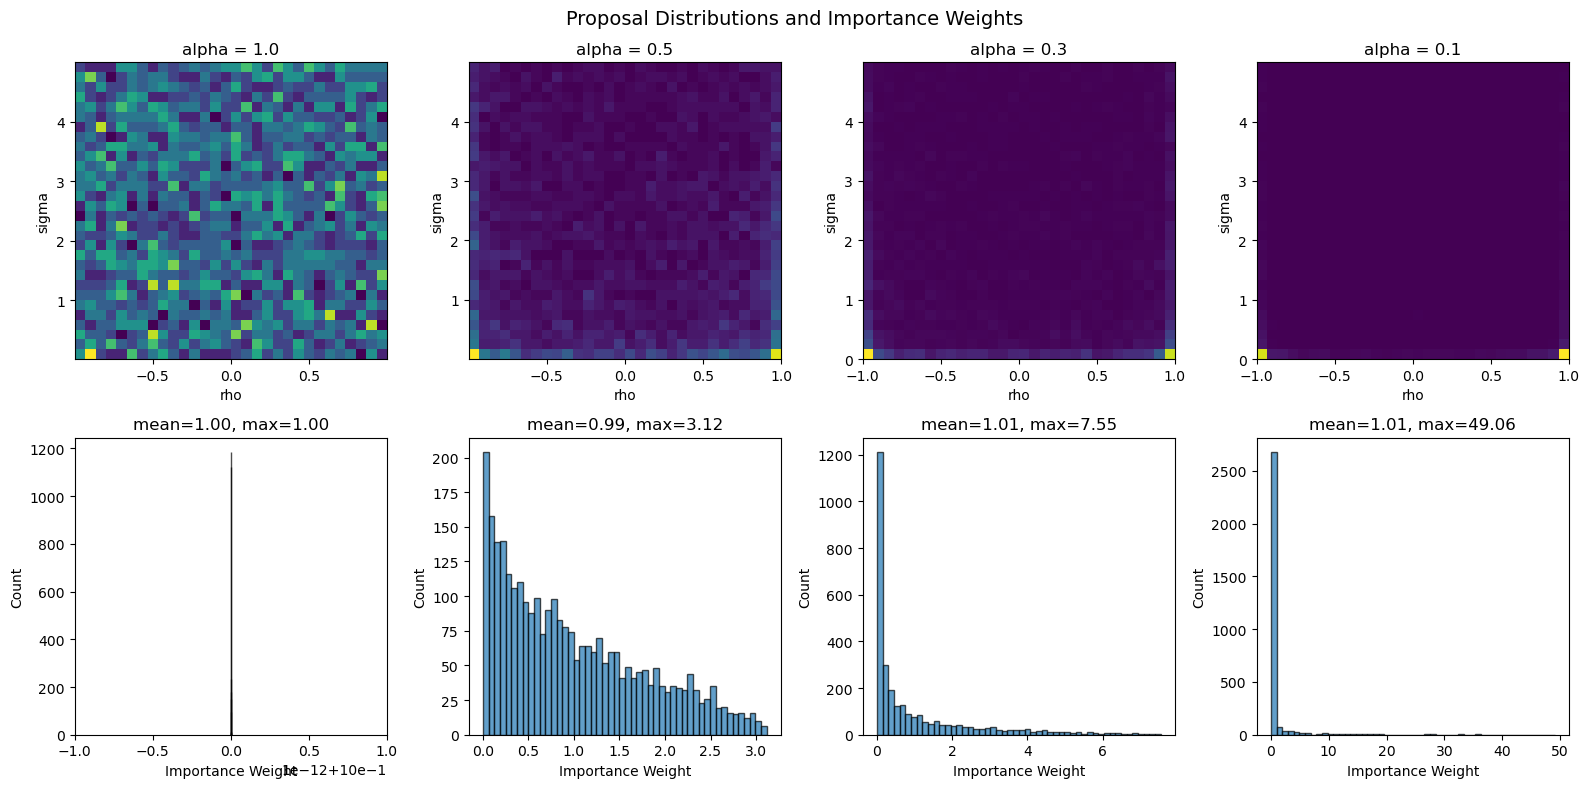

In [7]:
# Visualize proposal distributions
fig, axes = plt.subplots(2, len(ALPHA_VALUES), figsize=(16, 8))

for i, alpha in enumerate(ALPHA_VALUES):
    n = 3000
    rho, sigma = sample_from_proposal(n, alpha, alpha, BETA_SIGMA, A, device='cpu')
    rho = rho.numpy()
    sigma = sigma.numpy()
    
    weights = compute_importance_weights(rho, sigma, alpha, alpha, BETA_SIGMA, A)
    
    # Sample distribution
    axes[0, i].hist2d(rho, sigma, bins=30, cmap='viridis')
    axes[0, i].set_xlabel('rho')
    axes[0, i].set_ylabel('sigma')
    axes[0, i].set_title(f'alpha = {alpha}')
    
    # Weight distribution
    axes[1, i].hist(weights, bins=50, alpha=0.7, edgecolor='black')
    axes[1, i].set_xlabel('Importance Weight')
    axes[1, i].set_ylabel('Count')
    axes[1, i].set_title(f'mean={weights.mean():.2f}, max={weights.max():.2f}')

plt.suptitle('Proposal Distributions and Importance Weights', fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
def train_model(alpha_rho, alpha_sigma, beta_sigma, n_epochs, n_batches, batch_size, device):
    """Train a GRU model with specified importance sampling parameters"""
    
    model = GRUPosteriorEstimator(
        input_dim=1,
        hidden_dim=64,
        num_layers=2,
        mlp_hidden=64
    ).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.002)
    
    train_losses = []
    test_losses = []
    
    # Fixed test set (uniform sampling)
    rho_test = torch.empty(1024, device=device).uniform_(-1, 1)
    sigma_test = torch.empty(1024, device=device).uniform_(0, A)
    x_test = simulate_ar1_batch(rho_test, sigma_test, T, 1024, device=device)
    
    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0.0
        
        for batch_idx in range(n_batches):
            # Sample from proposal
            rho, sigma = sample_from_proposal(batch_size, alpha_rho, alpha_sigma, beta_sigma, A, device=device)
            
            # Compute importance weights
            weights = compute_importance_weights(rho, sigma, alpha_rho, alpha_sigma, beta_sigma, A)
            weights = torch.tensor(weights, dtype=torch.float32, device=device)
            weights = torch.nan_to_num(weights, nan=1.0, posinf=10.0, neginf=0.1)
            weights = torch.clamp(weights, min=0.1, max=10.0)
            weights = weights / weights.sum()
            
            # Simulate time series
            x = simulate_ar1_batch(rho, sigma, T, batch_size, device=device)
            
            if torch.isnan(x).any() or torch.isinf(x).any():
                continue
            
            # Forward pass
            theta_pred = model(x)
            
            if torch.isnan(theta_pred).any() or torch.isinf(theta_pred).any():
                continue
            
            # Weighted loss
            loss_per_sample = ((theta_pred - torch.stack([rho, sigma], dim=1))**2).sum(dim=1)
            loss = torch.sum(weights * loss_per_sample)
            
            if torch.isnan(loss) or torch.isinf(loss):
                continue
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_epoch_loss = epoch_loss / n_batches
        train_losses.append(avg_epoch_loss)
        
        # Test loss on uniform distribution
        model.eval()
        with torch.no_grad():
            theta_pred_test = model(x_test)
            test_loss = ((theta_pred_test - torch.stack([rho_test, sigma_test], dim=1))**2).mean().item()
            test_losses.append(test_loss)
    
    return model, train_losses, test_losses

print("Training function defined!")

Training function defined!


In [9]:
# Train models for each alpha value
models = {}
train_histories = {}
test_histories = {}

for alpha in ALPHA_VALUES:
    print(f"\n{'='*60}")
    print(f"Training with alpha = {alpha}")
    print(f"{'='*60}")
    
    model, train_losses, test_losses = train_model(
        alpha_rho=alpha,
        alpha_sigma=alpha,
        beta_sigma=BETA_SIGMA,
        n_epochs=N_EPOCHS,
        n_batches=N_BATCHES_PER_EPOCH,
        batch_size=TRAINING_BATCH_SIZE,
        device=device
    )
    
    models[alpha] = model
    train_histories[alpha] = train_losses
    test_histories[alpha] = test_losses
    
    print(f"Final train loss: {train_losses[-1]:.4f}")
    print(f"Final test loss: {test_losses[-1]:.4f}")

print("\n" + "="*60)
print("All models trained")
print("="*60)


Training with alpha = 1.0
Final train loss: 0.0728
Final test loss: 0.0340

Training with alpha = 0.5
Final train loss: 0.0754
Final test loss: 0.0380

Training with alpha = 0.3
Final train loss: 0.0831
Final test loss: 0.0369

Training with alpha = 0.1
Final train loss: 0.1025
Final test loss: 0.0473

All models trained


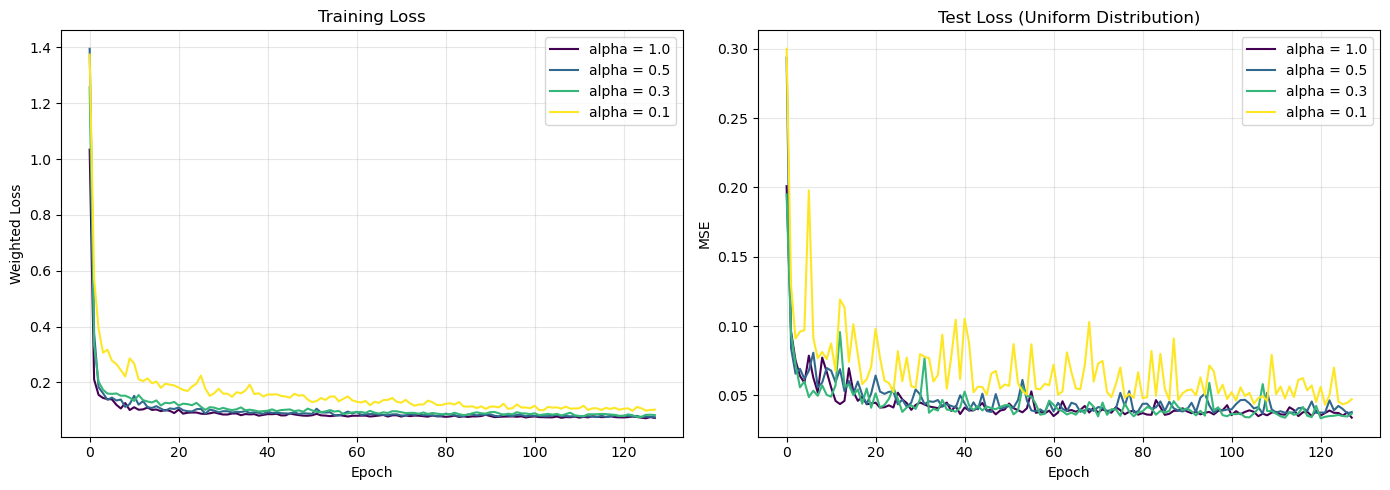

In [10]:
# Training and test loss curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.viridis(np.linspace(0, 1, len(ALPHA_VALUES)))

for i, alpha in enumerate(ALPHA_VALUES):
    axes[0].plot(train_histories[alpha], label=f'alpha = {alpha}', color=colors[i])
    axes[1].plot(test_histories[alpha], label=f'alpha = {alpha}', color=colors[i])

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Weighted Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE')
axes[1].set_title('Test Loss (Uniform Distribution)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## uniform evaluation

In [11]:
# Generate uniform test set
print(f"Generating {N_EVAL_POINTS} uniformly sampled test cases...")

rho_eval = torch.empty(N_EVAL_POINTS, device='cpu').uniform_(-1, 1)
sigma_eval = torch.empty(N_EVAL_POINTS, device='cpu').uniform_(0, A)
x_eval = simulate_ar1_batch(rho_eval, sigma_eval, T, N_EVAL_POINTS, device='cpu')

x_eval_np = x_eval.numpy()
rho_eval_np = rho_eval.numpy()
sigma_eval_np = sigma_eval.numpy()

print(f"Test set generated")

Generating 20000 uniformly sampled test cases...
Test set generated


In [12]:
# Gibbs sampler baseline
print("Running Gibbs sampler on test set...")

rho_gibbs_eval = np.zeros(N_EVAL_POINTS)
sigma_gibbs_eval = np.zeros(N_EVAL_POINTS)

for i in tqdm(range(N_EVAL_POINTS)):
    samples = gibbs(x_eval_np[i], n_iter=1000)
    rho_gibbs_eval[i] = np.mean(samples[:, 0])
    sigma_gibbs_eval[i] = np.mean(samples[:, 1])

print("Gibbs sampling complete")

Running Gibbs sampler on test set...


100%|██████████| 20000/20000 [02:14<00:00, 148.99it/s]

Gibbs sampling complete


In [13]:
# GRU predictions
predictions = {}

for alpha in ALPHA_VALUES:
    models[alpha].eval()
    with torch.no_grad():
        x_eval_gpu = x_eval.to(device)
        pred = models[alpha](x_eval_gpu).cpu().numpy()
        predictions[alpha] = {
            'rho': pred[:, 0],
            'sigma': pred[:, 1]
        }

print("Model predictions computed")

Model predictions computed


In [14]:
# Compute MSE for each alpha value
print("\n" + "="*80)
print("MEAN SQUARED ERROR COMPARISON")
print("="*80)
print(f"{'Method':<15} {'MSE (rho)':<15} {'MSE (sigma)':<15} {'Total MSE':<15}")
print("-"*80)

# Gibbs baseline
mse_rho_gibbs = np.mean((rho_eval_np - rho_gibbs_eval)**2)
mse_sigma_gibbs = np.mean((sigma_eval_np - sigma_gibbs_eval)**2)
total_gibbs = mse_rho_gibbs + mse_sigma_gibbs
print(f"{'Gibbs':<15} {mse_rho_gibbs:<15.6f} {mse_sigma_gibbs:<15.6f} {total_gibbs:<15.6f}")

results = {}
for alpha in ALPHA_VALUES:
    mse_rho = np.mean((rho_eval_np - predictions[alpha]['rho'])**2)
    mse_sigma = np.mean((sigma_eval_np - predictions[alpha]['sigma'])**2)
    total = mse_rho + mse_sigma
    
    results[alpha] = {
        'mse_rho': mse_rho,
        'mse_sigma': mse_sigma,
        'total': total
    }
    
    print(f"{'α = ' + str(alpha):<15} {mse_rho:<15.6f} {mse_sigma:<15.6f} {total:<15.6f}")

print("="*80)

# Find best alpha
best_alpha = min(results.keys(), key=lambda x: results[x]['total'])
print(f"\nBest α value: {best_alpha} (Total MSE: {results[best_alpha]['total']:.6f})")


MEAN SQUARED ERROR COMPARISON
Method          MSE (rho)       MSE (sigma)     Total MSE      
--------------------------------------------------------------------------------
Gibbs           0.011303        0.055370        0.066673       
α = 1.0         0.012856        0.059681        0.072538       
α = 0.5         0.014854        0.059954        0.074808       
α = 0.3         0.013544        0.066898        0.080443       
α = 0.1         0.017647        0.074878        0.092525       

Best α value: 1.0 (Total MSE: 0.072538)


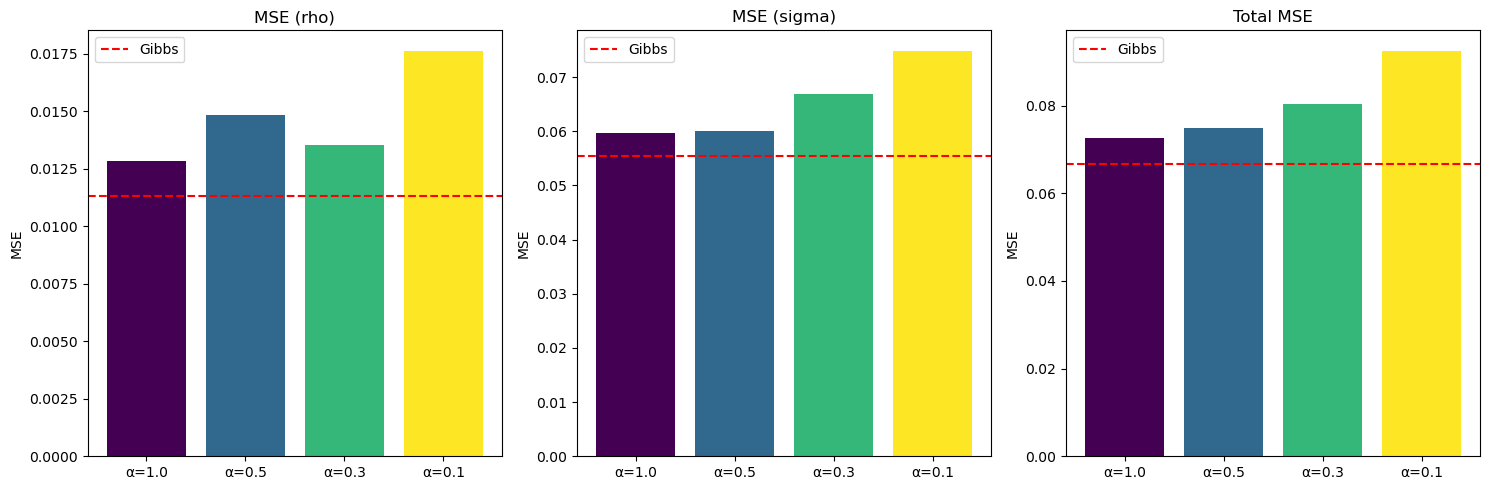

In [15]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

alphas_str = [f'α={a}' for a in ALPHA_VALUES]
x_pos = np.arange(len(ALPHA_VALUES))

# MSE rho
mse_rho_vals = [results[a]['mse_rho'] for a in ALPHA_VALUES]
axes[0].bar(x_pos, mse_rho_vals, color=colors)
axes[0].axhline(y=mse_rho_gibbs, color='r', linestyle='--', label='Gibbs')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(alphas_str)
axes[0].set_ylabel('MSE')
axes[0].set_title('MSE (rho)')
axes[0].legend()

# MSE sigma
mse_sigma_vals = [results[a]['mse_sigma'] for a in ALPHA_VALUES]
axes[1].bar(x_pos, mse_sigma_vals, color=colors)
axes[1].axhline(y=mse_sigma_gibbs, color='r', linestyle='--', label='Gibbs')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(alphas_str)
axes[1].set_ylabel('MSE')
axes[1].set_title('MSE (sigma)')
axes[1].legend()

# Total MSE
total_vals = [results[a]['total'] for a in ALPHA_VALUES]
axes[2].bar(x_pos, total_vals, color=colors)
axes[2].axhline(y=total_gibbs, color='r', linestyle='--', label='Gibbs')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(alphas_str)
axes[2].set_ylabel('MSE')
axes[2].set_title('Total MSE')
axes[2].legend()

plt.tight_layout()
plt.show()

## Prediction Quality: True vs Estimated Parameters

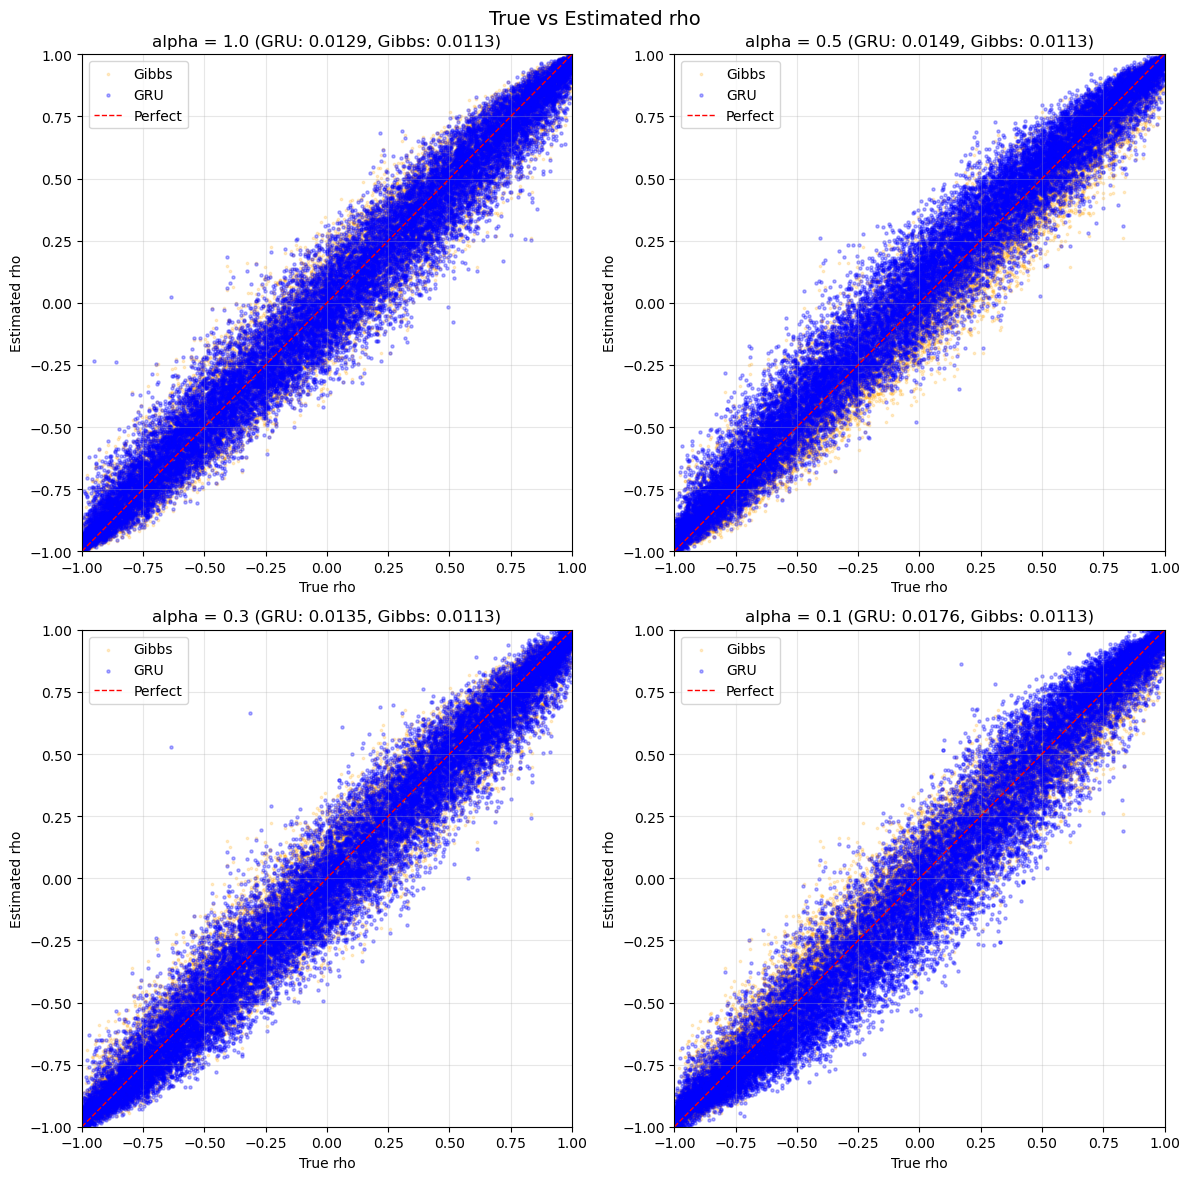

In [16]:
# True vs estimated rho
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for i, alpha in enumerate(ALPHA_VALUES):
    ax = axes[i]
    
    ax.scatter(rho_eval_np, rho_gibbs_eval, alpha=0.2, s=3, label='Gibbs', color='orange')
    ax.scatter(rho_eval_np, predictions[alpha]['rho'], alpha=0.3, s=5, label='GRU', color='blue')
    ax.plot([-1, 1], [-1, 1], 'r--', linewidth=1, label='Perfect')
    
    ax.set_xlabel('True rho')
    ax.set_ylabel('Estimated rho')
    ax.set_title(f'alpha = {alpha} (GRU: {results[alpha]["mse_rho"]:.4f}, Gibbs: {mse_rho_gibbs:.4f})')
    ax.set_xlim([-1, 1])
    ax.set_ylim([-1, 1])
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('True vs Estimated rho', fontsize=14)
plt.tight_layout()
plt.show()

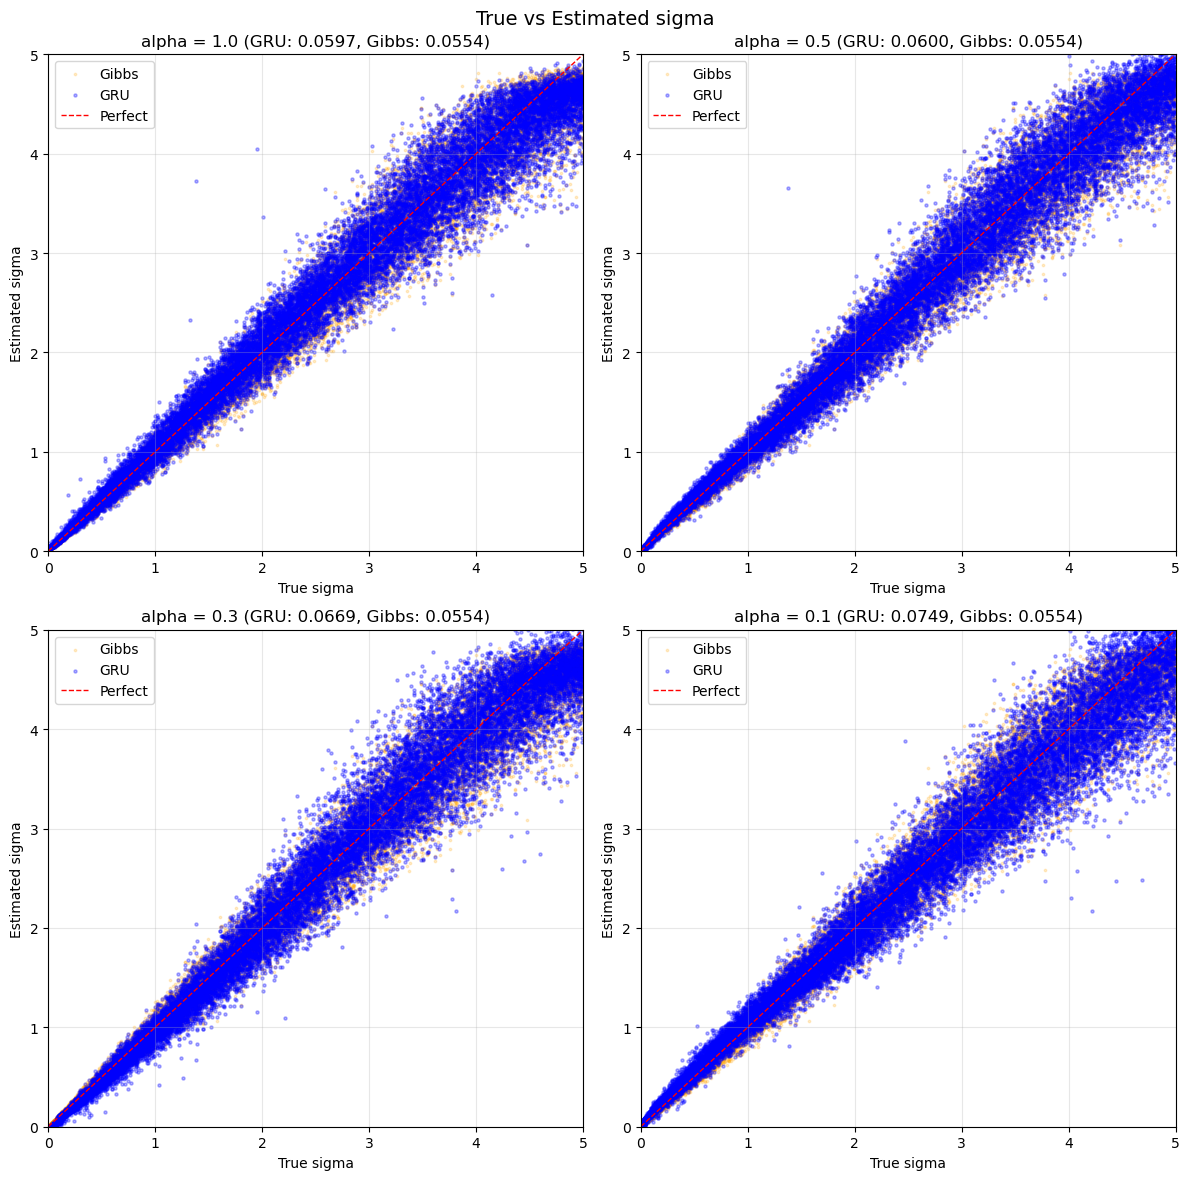

In [17]:
# True vs estimated sigma
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for i, alpha in enumerate(ALPHA_VALUES):
    ax = axes[i]
    
    ax.scatter(sigma_eval_np, sigma_gibbs_eval, alpha=0.2, s=3, label='Gibbs', color='orange')
    ax.scatter(sigma_eval_np, predictions[alpha]['sigma'], alpha=0.3, s=5, label='GRU', color='blue')
    ax.plot([0, A], [0, A], 'r--', linewidth=1, label='Perfect')
    
    ax.set_xlabel('True sigma')
    ax.set_ylabel('Estimated sigma')
    ax.set_title(f'alpha = {alpha} (GRU: {results[alpha]["mse_sigma"]:.4f}, Gibbs: {mse_sigma_gibbs:.4f})')
    ax.set_xlim([0, A])
    ax.set_ylim([0, A])
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('True vs Estimated sigma', fontsize=14)
plt.tight_layout()
plt.show()

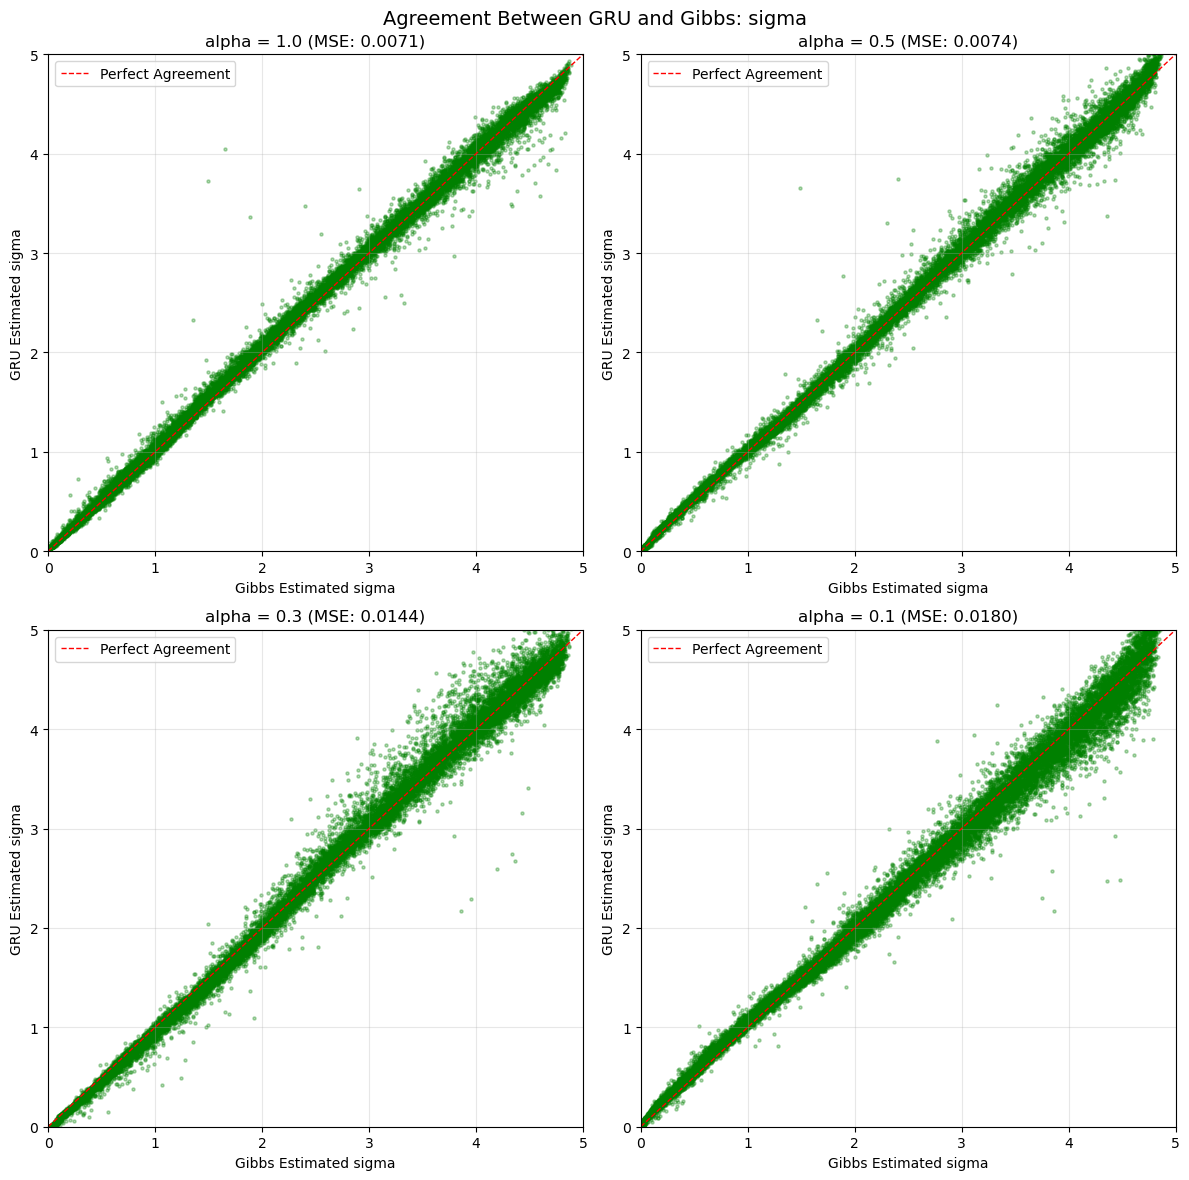

In [18]:
# GRU vs Gibbs agreement: sigma
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for i, alpha in enumerate(ALPHA_VALUES):
    ax = axes[i]
    
    ax.scatter(sigma_gibbs_eval, predictions[alpha]['sigma'], alpha=0.3, s=5, color='green')
    ax.plot([0, A], [0, A], 'r--', linewidth=1, label='Perfect Agreement')
    
    # MSE between methods
    mse_agreement = np.mean((sigma_gibbs_eval - predictions[alpha]['sigma'])**2)
    
    ax.set_xlabel('Gibbs Estimated sigma')
    ax.set_ylabel('GRU Estimated sigma')
    ax.set_title(f'alpha = {alpha} (MSE: {mse_agreement:.4f})')
    ax.set_xlim([0, A])
    ax.set_ylim([0, A])
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Agreement Between GRU and Gibbs: sigma', fontsize=14)
plt.tight_layout()
plt.show()

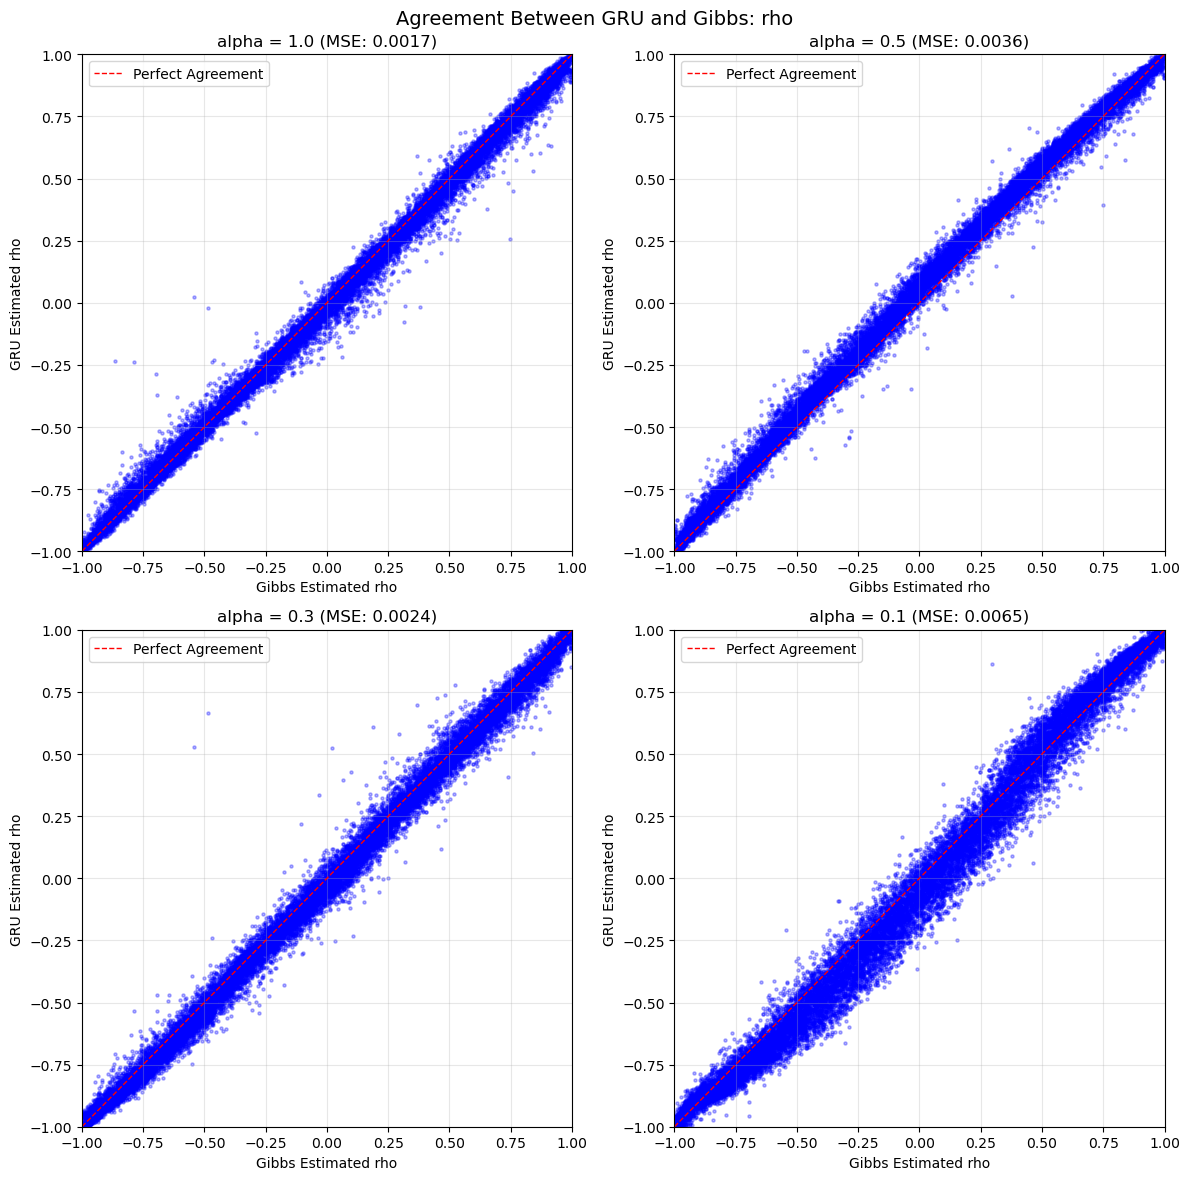

In [19]:
# GRU vs Gibbs agreement: rho
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for i, alpha in enumerate(ALPHA_VALUES):
    ax = axes[i]
    
    ax.scatter(rho_gibbs_eval, predictions[alpha]['rho'], alpha=0.3, s=5, color='blue')
    ax.plot([-1, 1], [-1, 1], 'r--', linewidth=1, label='Perfect Agreement')
    
    # MSE between methods
    mse_agreement = np.mean((rho_gibbs_eval - predictions[alpha]['rho'])**2)
    
    ax.set_xlabel('Gibbs Estimated rho')
    ax.set_ylabel('GRU Estimated rho')
    ax.set_title(f'alpha = {alpha} (MSE: {mse_agreement:.4f})')
    ax.set_xlim([-1, 1])
    ax.set_ylim([-1, 1])
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Agreement Between GRU and Gibbs: rho', fontsize=14)
plt.tight_layout()
plt.show()

## Agreement Between GRU and Gibbs

Beyond comparing to ground truth, we examine whether GRU and Gibbs produce similar estimates (even if both have error). This reveals whether the methods agree on difficult cases.

## Error Distribution Analysis

We examine the distribution of errors to understand bias and variance properties.

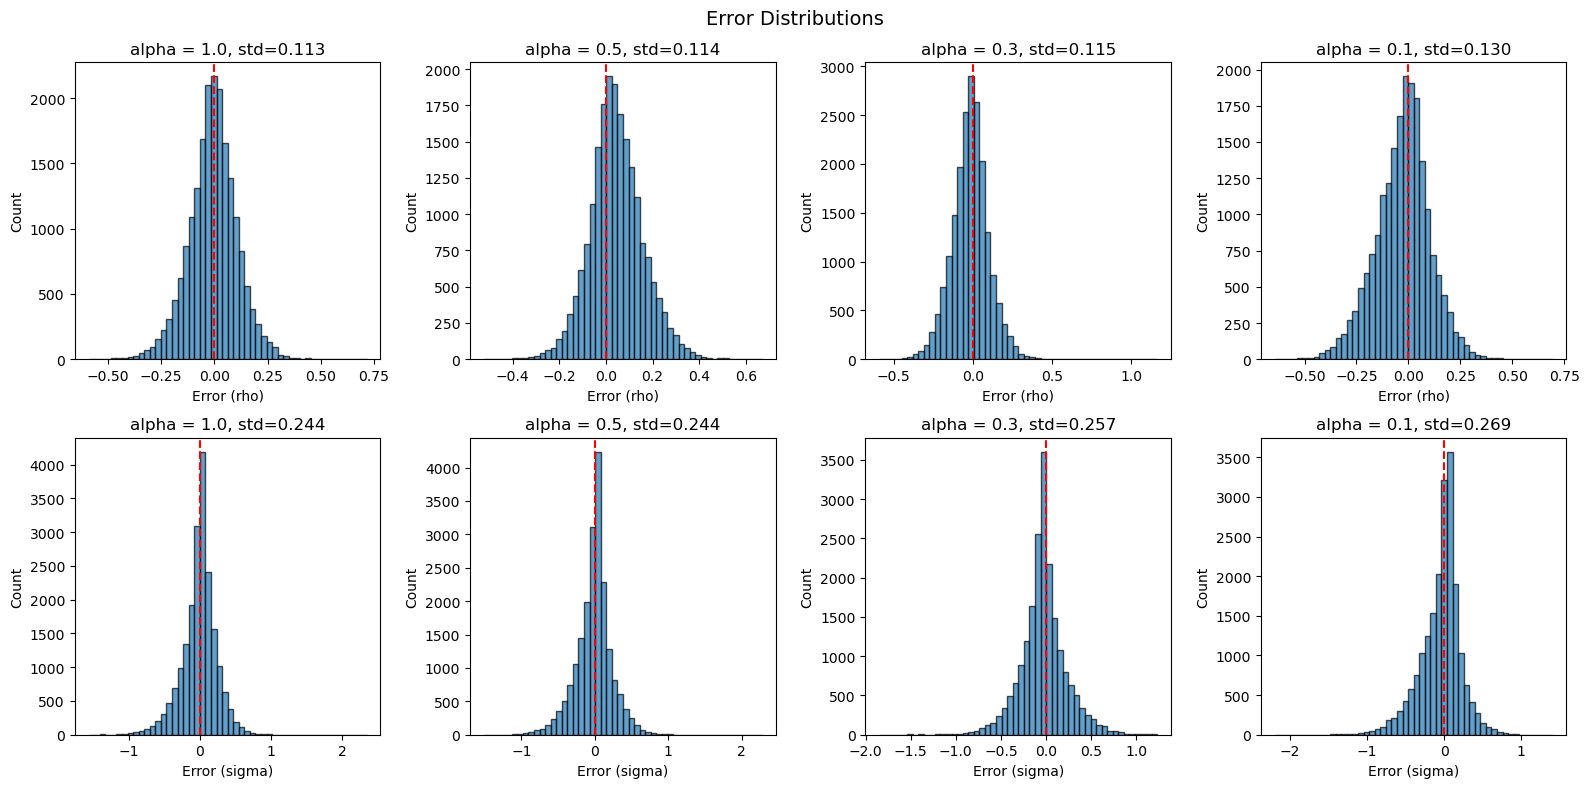

In [20]:
# Error distributions
fig, axes = plt.subplots(2, len(ALPHA_VALUES), figsize=(16, 8))

for i, alpha in enumerate(ALPHA_VALUES):
    rho_errors = predictions[alpha]['rho'] - rho_eval_np
    axes[0, i].hist(rho_errors, bins=50, alpha=0.7, edgecolor='black')
    axes[0, i].axvline(x=0, color='r', linestyle='--')
    axes[0, i].set_xlabel('Error (rho)')
    axes[0, i].set_ylabel('Count')
    axes[0, i].set_title(f'alpha = {alpha}, std={np.std(rho_errors):.3f}')
    
    sigma_errors = predictions[alpha]['sigma'] - sigma_eval_np
    axes[1, i].hist(sigma_errors, bins=50, alpha=0.7, edgecolor='black')
    axes[1, i].axvline(x=0, color='r', linestyle='--')
    axes[1, i].set_xlabel('Error (sigma)')
    axes[1, i].set_ylabel('Count')
    axes[1, i].set_title(f'alpha = {alpha}, std={np.std(sigma_errors):.3f}')

plt.suptitle('Error Distributions', fontsize=14)
plt.tight_layout()
plt.show()

## Performance in Boundary Regions

Importance sampling is designed to improve performance in challenging boundary regions. We analyze performance separately in:
- High $|\rho|$ region ($|\rho| > 0.95$)
- Low $\sigma$ region ($\sigma < 0.05$)
- High $\sigma$ region ($\sigma > 4.0$)

In [21]:
# Analyze performance at boundaries
# Define boundary regions
rho_boundary_mask = (np.abs(rho_eval_np) > 0.95)
sigma_low_mask = (sigma_eval_np < 0.05)
sigma_high_mask = (sigma_eval_np > 4.0)

print("\n" + "="*80)
print("BOUNDARY PERFORMANCE ANALYSIS")
print("="*80)

print(f"\nHigh |rho| region (|rho| > 0.95): {rho_boundary_mask.sum()} samples")
print(f"{'Method':<15} {'MSE (rho)':<15}")
print("-"*40)
print(f"{'Gibbs':<15} {np.mean((rho_eval_np[rho_boundary_mask] - rho_gibbs_eval[rho_boundary_mask])**2):<15.6f}")
for alpha in ALPHA_VALUES:
    mse = np.mean((rho_eval_np[rho_boundary_mask] - predictions[alpha]['rho'][rho_boundary_mask])**2)
    print(f"{'alpha = ' + str(alpha):<15} {mse:<15.6f}")

print(f"\nLow sigma region (sigma < 0.05): {sigma_low_mask.sum()} samples")
print(f"{'Method':<15} {'MSE (sigma)':<15}")
print("-"*40)
print(f"{'Gibbs':<15} {np.mean((sigma_eval_np[sigma_low_mask] - sigma_gibbs_eval[sigma_low_mask])**2):<15.6f}")
for alpha in ALPHA_VALUES:
    mse = np.mean((sigma_eval_np[sigma_low_mask] - predictions[alpha]['sigma'][sigma_low_mask])**2)
    print(f"{'alpha = ' + str(alpha):<15} {mse:<15.6f}")

print(f"\nHigh sigma region (sigma > 4.0): {sigma_high_mask.sum()} samples")
print(f"{'Method':<15} {'MSE (sigma)':<15}")
print("-"*40)
print(f"{'Gibbs':<15} {np.mean((sigma_eval_np[sigma_high_mask] - sigma_gibbs_eval[sigma_high_mask])**2):<15.6f}")
for alpha in ALPHA_VALUES:
    mse = np.mean((sigma_eval_np[sigma_high_mask] - predictions[alpha]['sigma'][sigma_high_mask])**2)
    print(f"{'alpha = ' + str(alpha):<15} {mse:<15.6f}")

print("="*80)


BOUNDARY PERFORMANCE ANALYSIS

High |rho| region (|rho| > 0.95): 986 samples
Method          MSE (rho)      
----------------------------------------
Gibbs           0.002730       
alpha = 1.0     0.004455       
alpha = 0.5     0.004274       
alpha = 0.3     0.003892       
alpha = 0.1     0.003409       

Low sigma region (sigma < 0.05): 186 samples
Method          MSE (sigma)    
----------------------------------------
Gibbs           0.000007       
alpha = 1.0     0.000404       
alpha = 0.5     0.000179       
alpha = 0.3     0.000443       
alpha = 0.1     0.000754       

High sigma region (sigma > 4.0): 4028 samples
Method          MSE (sigma)    
----------------------------------------
Gibbs           0.111059       
alpha = 1.0     0.120167       
alpha = 0.5     0.113994       
alpha = 0.3     0.117341       
alpha = 0.1     0.176994       


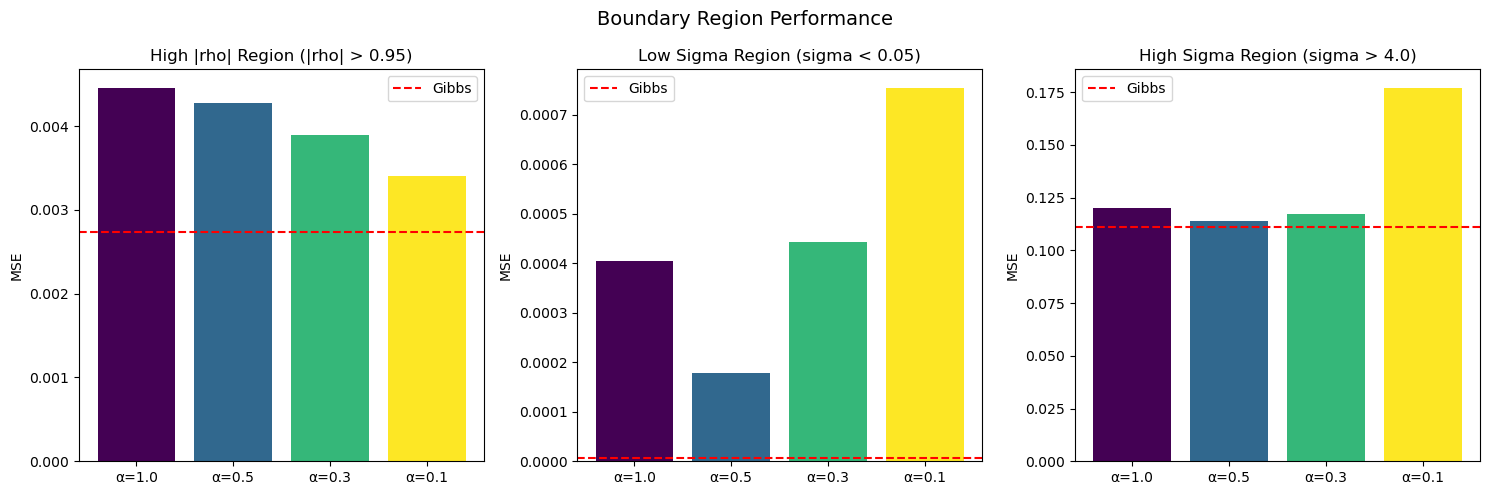

In [22]:
# Visualize boundary performance
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# High |rho| performance
rho_boundary_mse = [np.mean((rho_eval_np[rho_boundary_mask] - predictions[a]['rho'][rho_boundary_mask])**2) 
                   for a in ALPHA_VALUES]
gibbs_rho_boundary = np.mean((rho_eval_np[rho_boundary_mask] - rho_gibbs_eval[rho_boundary_mask])**2)

axes[0].bar(x_pos, rho_boundary_mse, color=colors)
axes[0].axhline(y=gibbs_rho_boundary, color='r', linestyle='--', label='Gibbs')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(alphas_str)
axes[0].set_ylabel('MSE')
axes[0].set_title('High |rho| Region (|rho| > 0.95)')
axes[0].legend()

# Low sigma performance
sigma_low_mse = [np.mean((sigma_eval_np[sigma_low_mask] - predictions[a]['sigma'][sigma_low_mask])**2) 
                for a in ALPHA_VALUES]
gibbs_sigma_low = np.mean((sigma_eval_np[sigma_low_mask] - sigma_gibbs_eval[sigma_low_mask])**2)

axes[1].bar(x_pos, sigma_low_mse, color=colors)
axes[1].axhline(y=gibbs_sigma_low, color='r', linestyle='--', label='Gibbs')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(alphas_str)
axes[1].set_ylabel('MSE')
axes[1].set_title('Low Sigma Region (sigma < 0.05)')
axes[1].legend()

# High sigma performance
sigma_high_mse = [np.mean((sigma_eval_np[sigma_high_mask] - predictions[a]['sigma'][sigma_high_mask])**2) 
                 for a in ALPHA_VALUES]
gibbs_sigma_high = np.mean((sigma_eval_np[sigma_high_mask] - sigma_gibbs_eval[sigma_high_mask])**2)

axes[2].bar(x_pos, sigma_high_mse, color=colors)
axes[2].axhline(y=gibbs_sigma_high, color='r', linestyle='--', label='Gibbs')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(alphas_str)
axes[2].set_ylabel('MSE')
axes[2].set_title('High Sigma Region (sigma > 4.0)')
axes[2].legend()

plt.suptitle('Boundary Region Performance', fontsize=14)
plt.tight_layout()
plt.show()

## Worst Case Analysis

We identify the cases where each model performs poorly to understand failure modes.

In [23]:
# Identify worst predictions for each alpha
print("\n" + "="*80)
print("WORST CASE ANALYSIS")
print("="*80)

for alpha in ALPHA_VALUES:
    total_errors = (predictions[alpha]['rho'] - rho_eval_np)**2 + (predictions[alpha]['sigma'] - sigma_eval_np)**2
    worst_indices = np.argsort(total_errors)[-5:]
    
    print(f"\nalpha = {alpha}:")
    print(f"{'Idx':<8} {'True rho':<12} {'Pred rho':<12} {'True sigma':<12} {'Pred sigma':<12} {'Total Error':<12}")
    print("-"*68)
    for idx in reversed(worst_indices):
        print(f"{idx:<8} {rho_eval_np[idx]:<12.3f} {predictions[alpha]['rho'][idx]:<12.3f} "
              f"{sigma_eval_np[idx]:<12.3f} {predictions[alpha]['sigma'][idx]:<12.3f} {total_errors[idx]:<12.4f}")


WORST CASE ANALYSIS

alpha = 1.0:
Idx      True rho     Pred rho     True sigma   Pred sigma   Total Error 
--------------------------------------------------------------------
15531    -1.000       -0.957       1.381        3.727        5.5043      
3635     0.999        0.923        1.952        4.045        4.3842      
5058     -0.992       -0.982       4.148        2.583        2.4503      
493      0.433        0.155        4.934        3.472        2.2144      
15507    0.152        -0.283       4.846        3.458        2.1165      

alpha = 0.5:
Idx      True rho     Pred rho     True sigma   Pred sigma   Total Error 
--------------------------------------------------------------------
15531    -1.000       -0.909       1.381        3.655        5.1782      
6992     0.613        0.471        4.795        3.286        2.2962      
493      0.433        0.267        4.934        3.515        2.0399      
5830     -0.542       -0.700       4.480        3.132        1.8439      

## End

In [24]:
# Summary
print("\n" + "="*80)
print("SUMMARY")
print("="*80)

print(f"\nEvaluation: {N_EVAL_POINTS} uniformly sampled test cases")
print(f"\nRanking by total MSE:")

sorted_alphas = sorted(results.keys(), key=lambda x: results[x]['total'])

for rank, alpha in enumerate(sorted_alphas, 1):
    improvement = (1 - results[alpha]['total']/total_gibbs) * 100
    print(f"{rank}. alpha = {alpha}: Total MSE = {results[alpha]['total']:.6f} "
          f"({improvement:.1f}% vs Gibbs)")

print(f"\nGibbs baseline: Total MSE = {total_gibbs:.6f}")

best_alpha = sorted_alphas[0]
print(f"\nBest performing: alpha = {best_alpha}")
print(f"  MSE (rho):   {results[best_alpha]['mse_rho']:.6f}")
print(f"  MSE (sigma): {results[best_alpha]['mse_sigma']:.6f}")
print(f"  Total MSE:   {results[best_alpha]['total']:.6f}")

print("\n" + "="*80)


SUMMARY

Evaluation: 20000 uniformly sampled test cases

Ranking by total MSE:
1. alpha = 1.0: Total MSE = 0.072538 (-8.8% vs Gibbs)
2. alpha = 0.5: Total MSE = 0.074808 (-12.2% vs Gibbs)
3. alpha = 0.3: Total MSE = 0.080443 (-20.7% vs Gibbs)
4. alpha = 0.1: Total MSE = 0.092525 (-38.8% vs Gibbs)

Gibbs baseline: Total MSE = 0.066673

Best performing: alpha = 1.0
  MSE (rho):   0.012856
  MSE (sigma): 0.059681
  Total MSE:   0.072538



In [25]:
# Quantitative summary of GRU-Gibbs differences
print("\n" + "="*80)
print("GRU vs GIBBS AGREEMENT ANALYSIS")
print("="*80)

for alpha in ALPHA_VALUES:
    rho_diff = predictions[alpha]['rho'] - rho_gibbs_eval
    sigma_diff = predictions[alpha]['sigma'] - sigma_gibbs_eval
    
    print(f"\nalpha = {alpha}:")
    print(f"  rho:   mean difference = {np.mean(rho_diff):>8.4f}, std = {np.std(rho_diff):>8.4f}, MSE = {np.mean(rho_diff**2):>8.4f}")
    print(f"  sigma: mean difference = {np.mean(sigma_diff):>8.4f}, std = {np.std(sigma_diff):>8.4f}, MSE = {np.mean(sigma_diff**2):>8.4f}")

print("\n" + "="*80)


GRU vs GIBBS AGREEMENT ANALYSIS

alpha = 1.0:
  rho:   mean difference =  -0.0084, std =   0.0400, MSE =   0.0017
  sigma: mean difference =   0.0238, std =   0.0808, MSE =   0.0071

alpha = 0.5:
  rho:   mean difference =   0.0434, std =   0.0408, MSE =   0.0036
  sigma: mean difference =   0.0201, std =   0.0838, MSE =   0.0074

alpha = 0.3:
  rho:   mean difference =  -0.0188, std =   0.0457, MSE =   0.0024
  sigma: mean difference =   0.0037, std =   0.1201, MSE =   0.0144

alpha = 0.1:
  rho:   mean difference =  -0.0290, std =   0.0754, MSE =   0.0065
  sigma: mean difference =  -0.0124, std =   0.1336, MSE =   0.0180



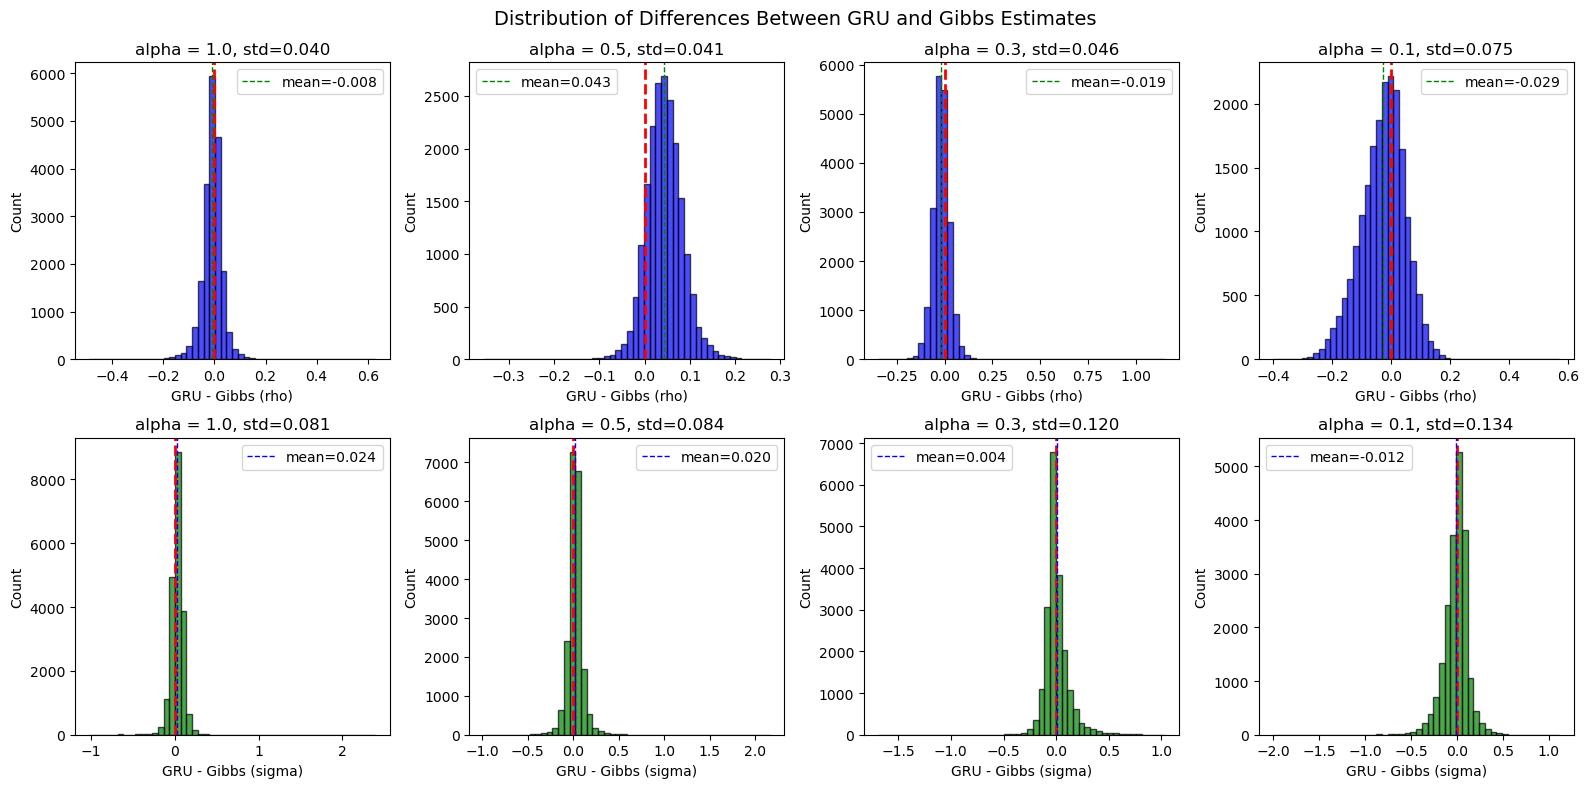

In [26]:
# Distribution of (GRU - Gibbs) errors
fig, axes = plt.subplots(2, len(ALPHA_VALUES), figsize=(16, 8))

for i, alpha in enumerate(ALPHA_VALUES):
    # Rho: difference from Gibbs
    rho_diff = predictions[alpha]['rho'] - rho_gibbs_eval
    axes[0, i].hist(rho_diff, bins=50, alpha=0.7, edgecolor='black', color='blue')
    axes[0, i].axvline(x=0, color='r', linestyle='--', linewidth=2)
    axes[0, i].axvline(x=np.mean(rho_diff), color='green', linestyle='--', linewidth=1, label=f'mean={np.mean(rho_diff):.3f}')
    axes[0, i].set_xlabel('GRU - Gibbs (rho)')
    axes[0, i].set_ylabel('Count')
    axes[0, i].set_title(f'alpha = {alpha}, std={np.std(rho_diff):.3f}')
    axes[0, i].legend()
    
    # Sigma: difference from Gibbs
    sigma_diff = predictions[alpha]['sigma'] - sigma_gibbs_eval
    axes[1, i].hist(sigma_diff, bins=50, alpha=0.7, edgecolor='black', color='green')
    axes[1, i].axvline(x=0, color='r', linestyle='--', linewidth=2)
    axes[1, i].axvline(x=np.mean(sigma_diff), color='blue', linestyle='--', linewidth=1, label=f'mean={np.mean(sigma_diff):.3f}')
    axes[1, i].set_xlabel('GRU - Gibbs (sigma)')
    axes[1, i].set_ylabel('Count')
    axes[1, i].set_title(f'alpha = {alpha}, std={np.std(sigma_diff):.3f}')
    axes[1, i].legend()

plt.suptitle('Distribution of Differences Between GRU and Gibbs Estimates', fontsize=14)
plt.tight_layout()
plt.show()

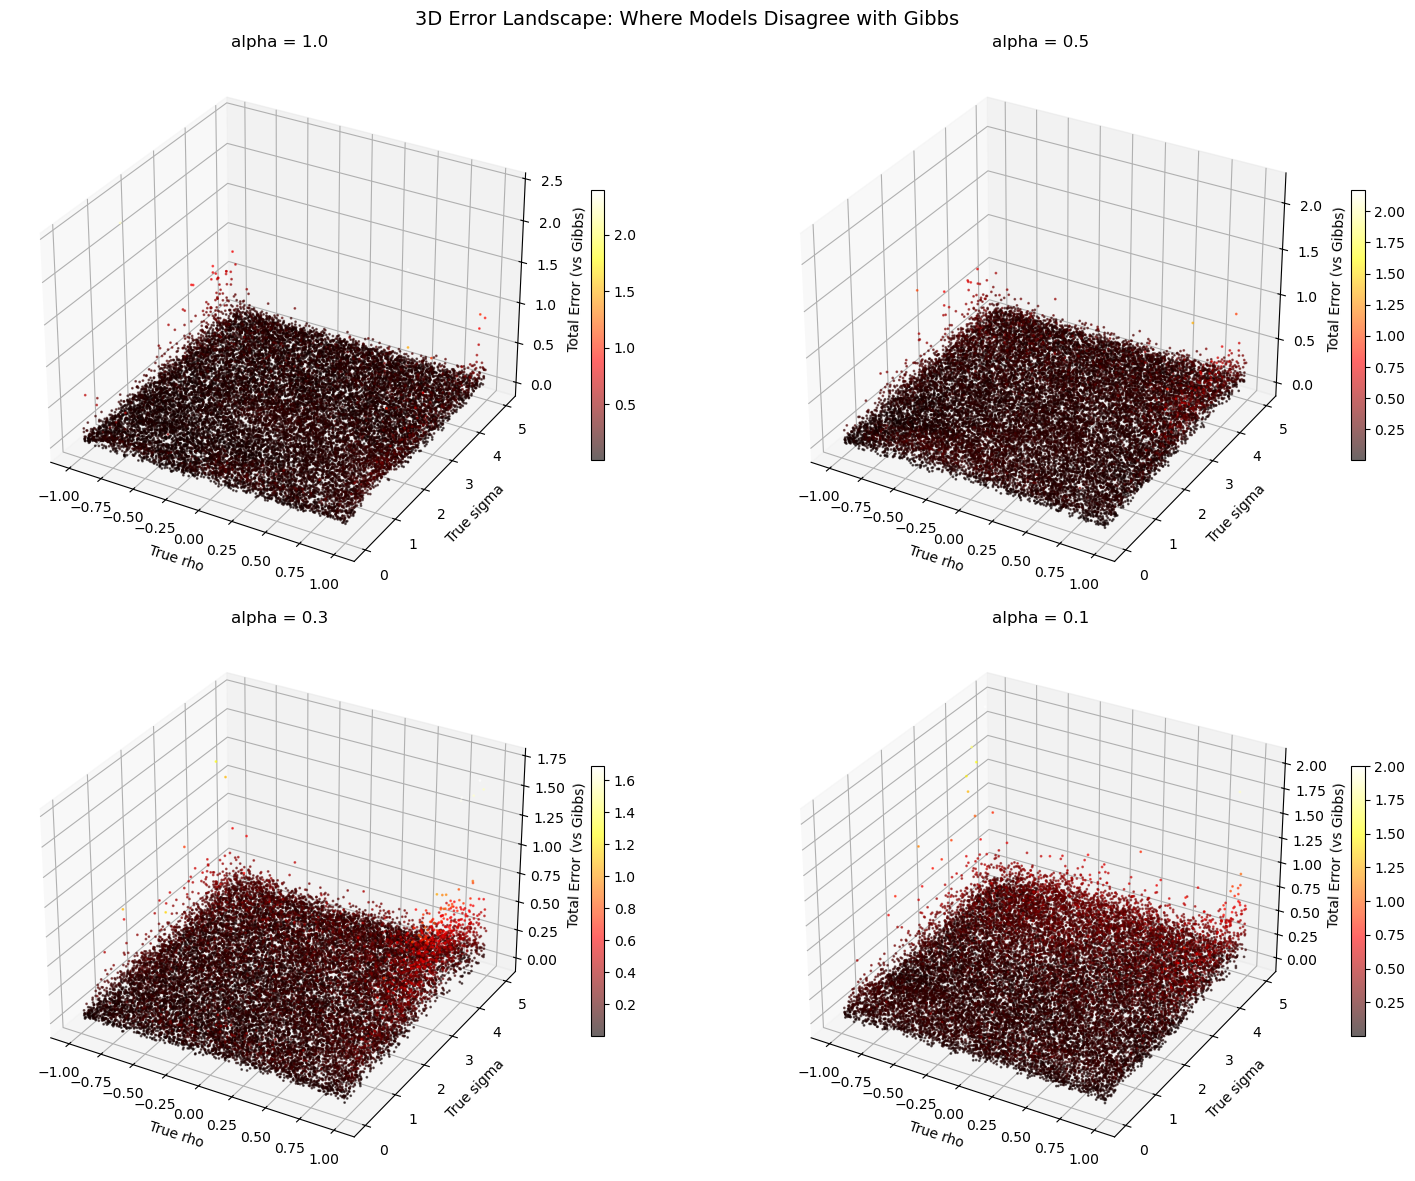

In [27]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from scipy.interpolate import griddata

# Compute errors for each alpha
errors_by_alpha = {}
for alpha in ALPHA_VALUES:
    rho_err = np.abs(predictions[alpha]['rho'] - rho_gibbs_eval)
    sigma_err = np.abs(predictions[alpha]['sigma'] - sigma_gibbs_eval)
    total_err = np.sqrt(rho_err**2 + sigma_err**2)

    errors_by_alpha[alpha] = {
        'rho_err': rho_err,
        'sigma_err': sigma_err,
        'total_err': total_err
    }

# Visualization 1: 3D Scatter - (rho, sigma, total_error)
fig = plt.figure(figsize=(16, 12))

for i, alpha in enumerate(ALPHA_VALUES):
    ax = fig.add_subplot(2, 2, i+1, projection='3d')

    total_err = errors_by_alpha[alpha]['total_err']

    # Color by error magnitude
    scatter = ax.scatter(rho_eval_np, sigma_eval_np, total_err,
                        c=total_err, cmap='hot', s=1, alpha=0.6)

    ax.set_xlabel('True rho')
    ax.set_ylabel('True sigma')
    ax.set_zlabel('Total Error (vs Gibbs)')
    ax.set_title(f'alpha = {alpha}')

    # Add colorbar
    plt.colorbar(scatter, ax=ax, shrink=0.5)

plt.suptitle('3D Error Landscape: Where Models Disagree with Gibbs', fontsize=14)
plt.tight_layout()
plt.show()
